In [63]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

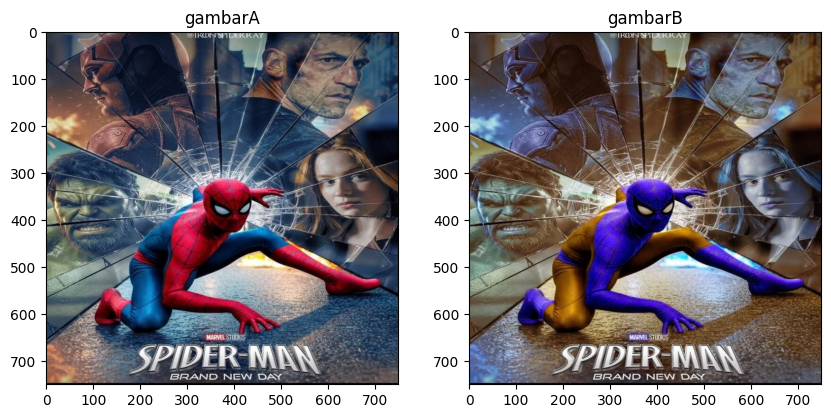

In [64]:
gambarA = plt.imread("brandnewday.jpg")
gambarB = cv.imread("brandnewday.jpg")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("gambarA")
plt.imshow(gambarA)

plt.subplot(1, 2, 2)
plt.title("gambarB")
plt.imshow(gambarB)
plt.show()

## Analisis

Kedua gambar di atas terjadi perbedaan, karna OpenCV (cv.imread) membaca gambar dalam format BGR (Blue, Green, Red), sedangkan Matplotlib menampilkan gambar dalam format RGB (Red, Green, Blue). Jadi ada pergesaran warna dari hasil kedua gambar tersebut.

In [65]:
grayA = cv.cvtColor(gambarA, cv.COLOR_RGB2GRAY)

RA = gambarA[:, :, 0]
GA = gambarA[:, :, 1]
BA = gambarA[:, :, 2]


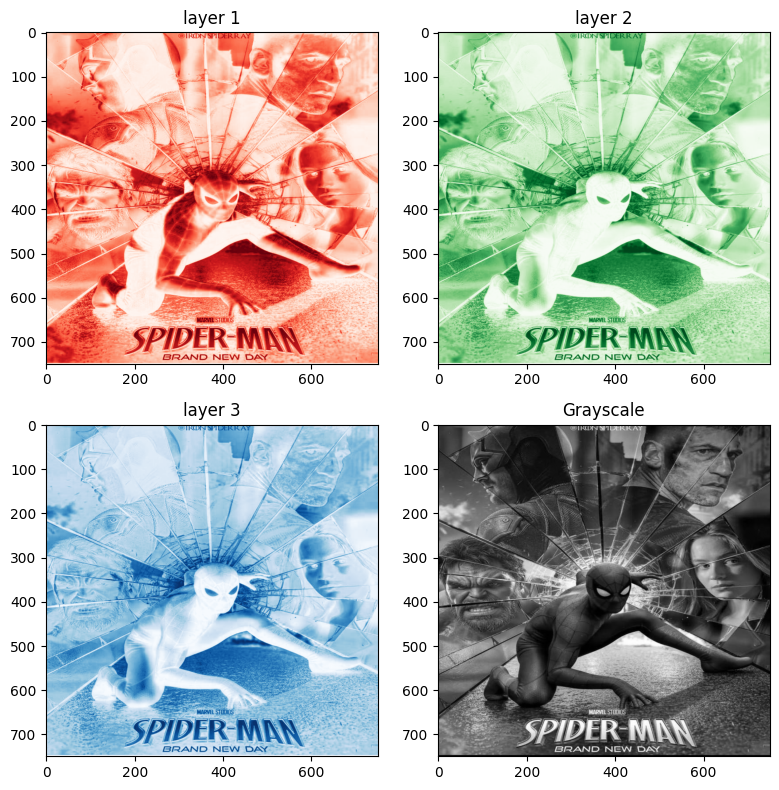

In [66]:
plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("layer 1")
plt.imshow(RA, cmap="Reds")

plt.subplot(2, 2, 2)
plt.title("layer 2")
plt.imshow(GA, cmap="Greens")

plt.subplot(2, 2, 3)
plt.title("layer 3")
plt.imshow(BA, cmap="Blues")

plt.subplot(2, 2, 4)
plt.title("Grayscale")
plt.imshow(grayA, cmap="gray")

plt.tight_layout()
plt.show()

In [67]:
grayB = cv.cvtColor(gambarB, cv.COLOR_RGB2GRAY)

BB = gambarB[:, :, 0]
GB = gambarB[:, :, 1]
RB = gambarB[:, :, 2]

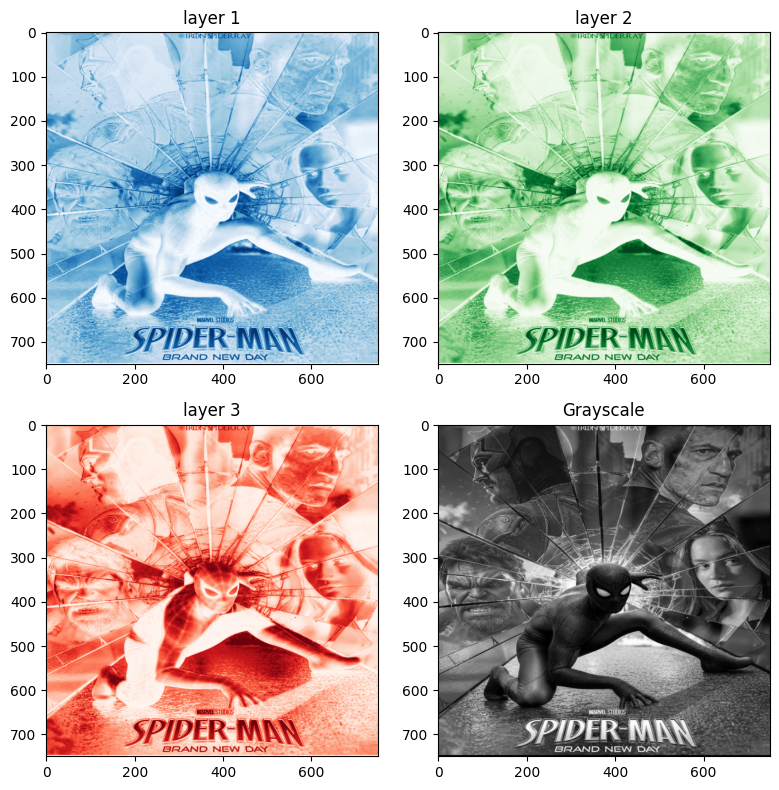

In [68]:
plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("layer 1")
plt.imshow(BB, cmap="Blues")

plt.subplot(2, 2, 2)
plt.title("layer 2")
plt.imshow(GB, cmap="Greens")

plt.subplot(2, 2, 3)
plt.title("layer 3")
plt.imshow(RB, cmap="Reds")

plt.subplot(2, 2, 4)
plt.title("Grayscale")
plt.imshow(grayB, cmap="gray")

plt.tight_layout()
plt.show()

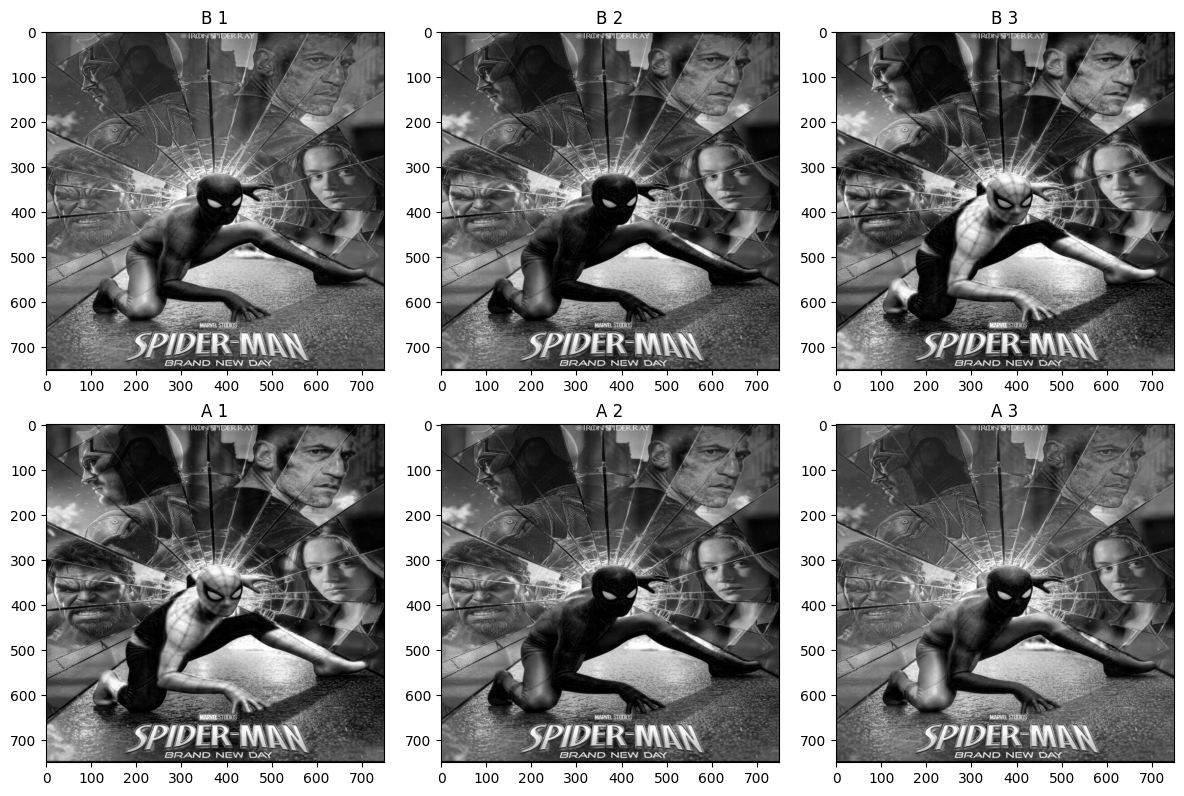

In [69]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("B 1")
plt.imshow(BB, cmap="gray")

plt.subplot(2, 3, 2)
plt.title("B 2")
plt.imshow(GB, cmap="gray")

plt.subplot(2, 3, 3)
plt.title("B 3")
plt.imshow(RB, cmap="gray")

plt.subplot(2, 3, 4)
plt.title("A 1")
plt.imshow(RA, cmap="gray")

plt.subplot(2, 3, 5)
plt.title("A 2")
plt.imshow(GA, cmap="gray")

plt.subplot(2, 3, 6)
plt.title("A 3")
plt.imshow(BA, cmap="gray")

plt.tight_layout()
plt.show()

Hasilnya gambar A dan B tetap sama karena file sumbernya sama. Tiap layer cuma nunjukin intensitas warna masing-masing, R buat merah, G buat hijau, B buat biru. Dari sini kelihatan bagian mana yang paling dominan warnanya di tiap channel. Jadi, bukan gambar beda, cuma dipecah jadi 3 layer warna aja buat lihat struktur warnanya dominannya.

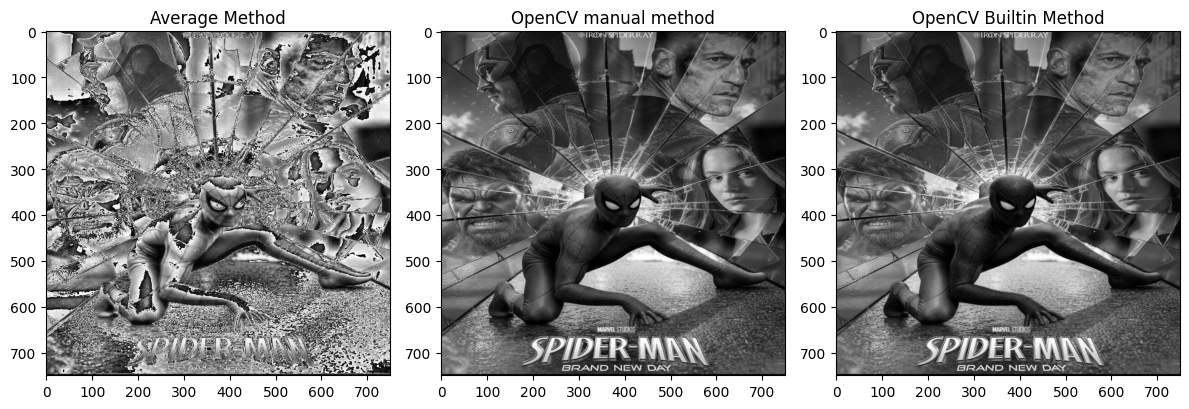

In [75]:
gray_avg = (RB + GB + BB) / 3

gray_manual = 0.299 * RB + 0.587 * GB + 0.114 * BB


plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Average Method")
plt.imshow(gray_avg, cmap="gray")

plt.subplot(1, 3, 2)
plt.title("OpenCV manual method")
plt.imshow(gray_manual, cmap="gray")

plt.subplot(1, 3, 3)
plt.title("OpenCV Builtin Method")
plt.imshow(grayB, cmap="gray")

plt.tight_layout()
plt.show()

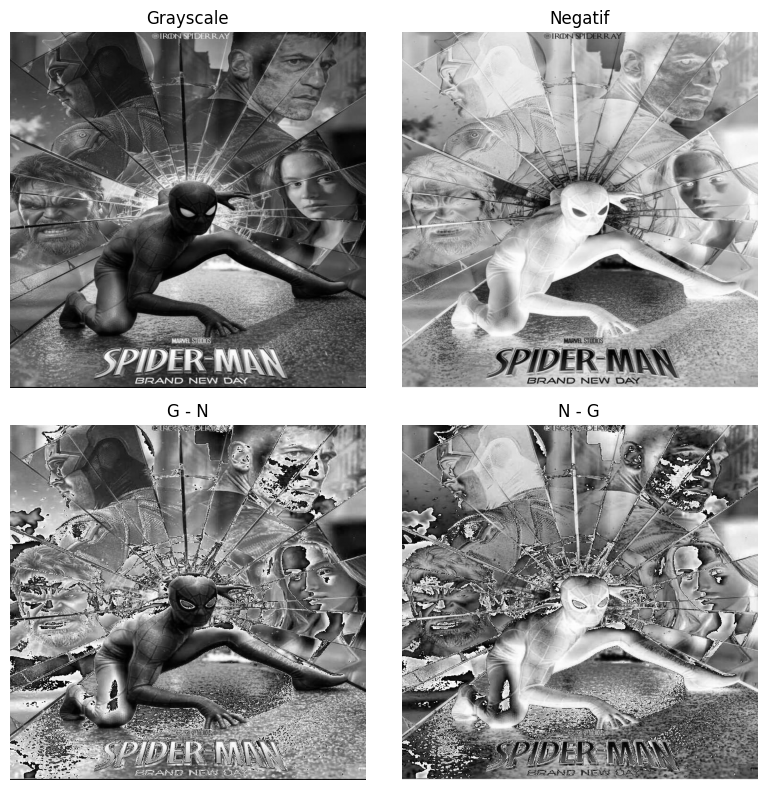

In [76]:
negatif = 255 - grayB

gKurangN = grayB - negatif
nKurangG = negatif - grayB

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Grayscale")
plt.imshow(grayB, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Negatif")
plt.imshow(negatif, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("G - N")
plt.imshow(gKurangN, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("N - G")
plt.imshow(nKurangG, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

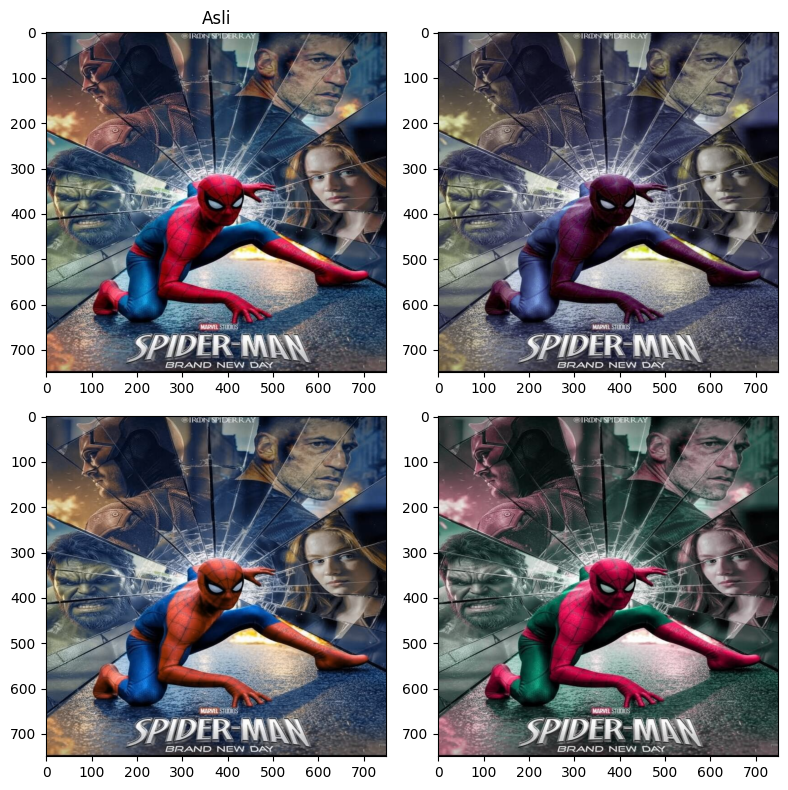

In [80]:
img_R = gambarA.copy()
img_G = gambarA.copy()
img_B = gambarA.copy()

img_R[:, :, 0] = grayA
img_G[:, :, 1] = grayA
img_B[:, :, 2] = grayA

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Asli")
plt.imshow(gambarA)

plt.subplot(2, 2, 2)
plt.imshow(img_R)

plt.subplot(2, 2, 3)
plt.imshow(img_G)

plt.subplot(2, 2, 4)
plt.imshow(img_B)

plt.tight_layout()
plt.show()

In [81]:
def rotasi_sudut(image, derajat):
    h, w = image.shape
    
    rad = derajat * np.pi / 180
    cos_a = np.cos(rad)
    sin_a = np.sin(rad)

    cx = w / 2
    cy = h / 2

    rx0 = cos_a * (0 - cx) - sin_a * (0 - cy) + cx
    ry0 = sin_a * (0 - cx) + cos_a * (0 - cy) + cy

    rx1 = cos_a * (w - cx) - sin_a * (0 - cy) + cx
    ry1 = sin_a * (w - cx) + cos_a * (0 - cy) + cy

    rx2 = cos_a * (0 - cx) - sin_a * (h - cy) + cx
    ry2 = sin_a * (0 - cx) + cos_a * (h - cy) + cy

    rx3 = cos_a * (w - cx) - sin_a * (h - cy) + cx
    ry3 = sin_a * (w - cx) + cos_a * (h - cy) + cy

    new_w = int(max([rx0, rx1, rx2, rx3]) - min([rx0, rx1, rx2, rx3])) + 1
    new_h = int(max([ry0, ry1, ry2, ry3]) - min([ry0, ry1, ry2, ry3])) + 1

    ox = (new_w - w) / 2
    oy = (new_h - h) / 2

    hasil = np.zeros((new_h, new_w), dtype=image.dtype)

    for i in range(new_h):
        for j in range(new_w):
            x0 = j - ox - cx
            y0 = i - oy - cy

            xr = int(cos_a * x0 + sin_a * y0 + cx)
            yr = int(-sin_a * x0 + cos_a * y0 + cy)

            if 0 <= xr < w and 0 <= yr < h:
                hasil[i, j] = image[yr, xr]

    return hasil

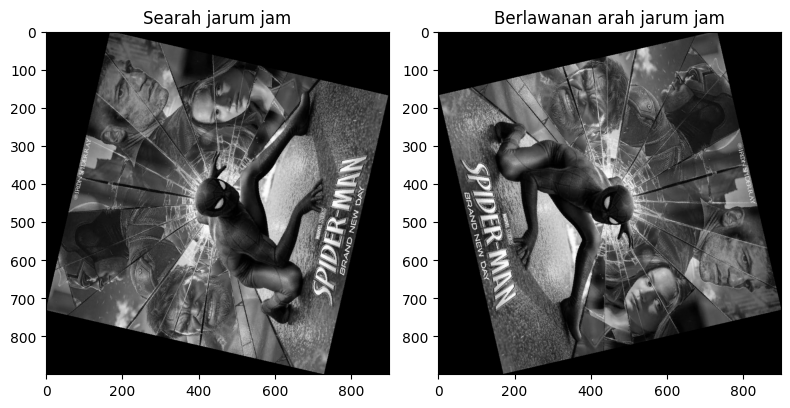

In [85]:
rotasiKanan = rotasi_sudut(grayB, -77)
rotasiKiri = rotasi_sudut(grayB, 77)

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Searah jarum jam")
plt.imshow(rotasiKanan, cmap="gray")

plt.subplot(2, 2, 2)
plt.title("Berlawanan arah jarum jam")
plt.imshow(rotasiKiri, cmap="gray")

plt.tight_layout()
plt.show()

In [ ]:
def fungsi_empat_R(image, val):
h, w = image.shape
val = int(val) % 360
if val == 0: return image
elif val == 90:
rot = np.zeros((w, h), dtype=image.dtype)
for i in range(h):
for j in range(w): rot[j, h - 1 - i] = image[i, j]
return rot
elif val == 180:
rot = np.zeros_like(image, dtype=image.dtype)
for i in range(h):
for j in range(w): rot[h - 1 - i, w - 1 - j] =
image[i, j]
return rot
elif val == 270:
rot = np.zeros((w, h), dtype=image.dtype)
for i in range(h):
for j in range(w): rot[w - 1 - j, i] = image[i, j]
return rot
return image